# Router-training datasets — lineage, augmentation, and taxonomy

This notebook explains the two training populations that matter at the end of the
project rather than treating the 233K union as a black box:

- **`union_233k`** — `cascade ∪ v2 ∪ v3 ∪ v3_aug`, deduplicated on
  `(dataset, query_id)` with cascade winning collisions.
- **`last_os_distill`** — the 91K cascade/relabel artifact used by the current
  relabel experiments. It is a subset of `union_233k`, not an independent control.

The questions are deliberately ordered:

1. Where did rows come from after deduplication?
2. How much natural, synthetic, augmented, and document-grounded material does each
   selected dataset contain — overall and by lane?
3. Which part of the cascade created route decisions, and which rows remain unresolved?
4. How concentrated are the lanes and route decisions?
5. What can the available taxonomy catalog actually support?

**Important semantics.** `route` is the stored route decision; it remains null when
the source has no defensible decision. We do not use a positional score argmax as a
route label because that silently turns ties into `dense_only`. The cascade has mixed
label layers: its depth-100 fallback is shown as a provenance layer, never silently
merged into a Top-10 metric claim. All analysis is read-only and uses local artifacts.


## 0 · Setup

In [1]:
from __future__ import annotations

import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hybrid_search_rrf_dataset.labels import AcceptabilityLabels
from hybrid_search_rrf_dataset.objective import RouterObjective
from encoder_router.table import KEY, ROUTES
from composition.cells import CELLS
from composition.compose import DEFAULT_CATALOG
from composition.floors import with_derived


def find_data_dir(start: Path) -> Path:
    for directory in (start.resolve(), *start.resolve().parents):
        if (directory / "src" / "data").is_dir():
            return directory / "src" / "data"
    raise FileNotFoundError(f"could not find src/data above {start}")


DATA_DIR = find_data_dir(Path.cwd())
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.max_rows", 100)
ROUTE_COLS = [f"score_{route}" for route in ROUTES]
STRICT_MARGIN = RouterObjective().decisive_margin
print("data dir:", DATA_DIR, "| routes:", ROUTES, "| strict margin:", STRICT_MARGIN)


data dir: /Users/andrei/projects/hybrid-search-rrf-dataset/src/data | routes: ('dense_only', 'pure_rrf', 'sparse_only') | strict margin: 0.39999999999999997


## 1 · Load artifacts with their stored decision semantics

The cascade keeps its canonical stored score vector and stored `route`. The earlier
notebook rebuilt a clean `argmax(l1,l2)` vector, which erased every depth-100 recovery
from the route picture and made score ties look dense by column order. This loader
keeps the two concepts separate: score-derived **shape** is diagnostic; stored
**decision** is the artifact's actual decision state.


In [2]:
CANON = list(KEY) + ["query", "route", "label_layer", "provenance", "stage", *ROUTE_COLS]


def _text_rows(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["query"].notna() & df["query"].astype(str).str.strip().ne("")].copy()


def _standardise(df: pd.DataFrame, source: str, *, fallback_provenance: str) -> pd.DataFrame:
    out = _text_rows(df)
    out["query_id"] = out["query_id"].astype(str)
    for column in ("route", "label_layer", "provenance", "stage"):
        if column not in out:
            out[column] = pd.NA
    out["provenance"] = out["provenance"].fillna(fallback_provenance)
    out["label_layer"] = out["label_layer"].fillna(source)
    out["_source"] = source
    return out[CANON + ["_source"]]


def load_cascade() -> pd.DataFrame:
    labels = pd.read_parquet(
        DATA_DIR / "legb_pilot" / "os_distill_relabel" / "cascade_labels.parquet"
    )
    planned = pd.read_parquet(DATA_DIR / "rungs" / "100k-v2" / "planned_set.parquet")
    labels["query_id"] = labels["query_id"].astype(str)
    planned["query_id"] = planned["query_id"].astype(str)
    provenance = planned[list(KEY) + ["provenance"]].drop_duplicates(KEY)
    labels = labels.drop(columns="provenance", errors="ignore").merge(
        provenance, on=list(KEY), how="left", validate="one_to_one"
    )
    assert labels["provenance"].notna().all(), "cascade rows lost planned-set provenance"
    return _standardise(labels, "cascade", fallback_provenance="unknown")


CASCADE = load_cascade()
V2 = _standardise(
    pd.read_parquet(DATA_DIR / "route_labels" / "labels.parquet"),
    "v2", fallback_provenance="legacy_v2",
)
V3 = _standardise(
    pd.read_parquet(DATA_DIR / "v3" / "labels.parquet"),
    "v3", fallback_provenance="natural",
)
V3_AUG = _standardise(
    pd.read_parquet(DATA_DIR / "v3" / "augmented" / "labels.parquet"),
    "v3_aug", fallback_provenance="unknown",
)
RAW_SOURCES = {"v2": V2, "v3": V3, "v3_aug": V3_AUG, "cascade": CASCADE}

# Cascade is last, so it wins key collisions exactly as in the volume probe.
UNION = pd.concat([V2, V3, V3_AUG, CASCADE], ignore_index=True).drop_duplicates(
    list(KEY), keep="last"
).reset_index(drop=True)

V3_SELECTED = pd.read_parquet(DATA_DIR / "v3" / "dataset_v3.parquet")
FINAL_PLANNED = pd.read_parquet(DATA_DIR / "rungs" / "100k-v2" / "planned_set.parquet")


def annotated(df: pd.DataFrame) -> pd.DataFrame:
    lab = AcceptabilityLabels(df[CANON], tolerance=None).frame().reset_index(drop=True)
    lab["_source"] = df["_source"].to_numpy()
    lab["decision"] = lab["route"].fillna("unresolved")
    scores = lab[ROUTE_COLS].to_numpy(float)
    ordered = np.sort(scores, axis=1)
    lab["strict_margin"] = ordered[:, -1] - ordered[:, -2]
    lab["strict_decisive"] = lab["strict_margin"] >= STRICT_MARGIN
    return lab


TARGETS = {"union_233k": annotated(UNION), "last_os_distill": annotated(CASCADE)}
display(pd.DataFrame({
    name: {"rows": len(frame), "lanes": frame["dataset"].nunique(),
           "stored decisions": int(frame["route"].notna().sum())}
    for name, frame in TARGETS.items()
}).T)


,rows,lanes,stored decisions
union_233k,233247,46,166188
last_os_distill,91080,46,56047


## 2 · Lineage: the 233K union is a deduplicated mixture

The union is not a fifth independently composed dataset. This section shows both
the raw inputs and the source retained after collision resolution. The two largest
surviving sources are v3 augmentation and the cascade; source share should therefore
precede any statement about its taxonomy or route balance.


,raw text rows,lanes,surviving union rows,retained share
v3_aug,107120,40,91280,39.1%
cascade,91080,46,91080,39.0%
v3,71953,28,35005,15.0%
v2,46142,42,15882,6.8%


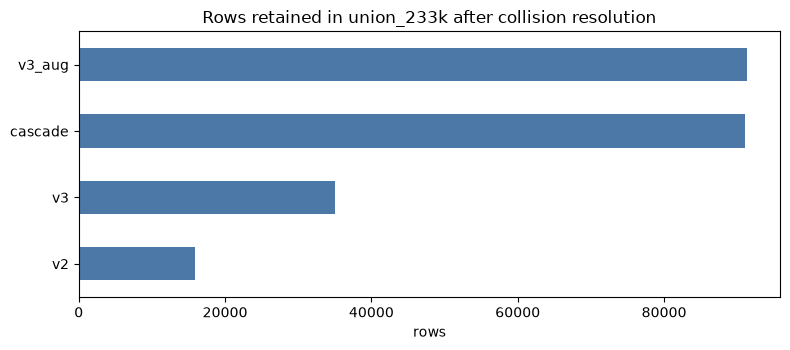

_source,cascade,v2,v3,v3_aug,n
dataset,,,,,
scirgen-geo-en,0.324,0.087,0.566,0.023,61797
quest,0.367,0.000,0.000,0.633,47287
clerc,0.135,0.034,0.000,0.832,15190
freshstack-laravel,0.020,0.000,0.000,0.980,9288
crumb-clinical-trial,0.016,0.000,0.000,0.984,8776
webfaq-eng,0.797,0.203,0.000,0.000,8623
crumb-legal-qa,0.875,0.000,0.000,0.125,8000
rarb-math,0.844,0.000,0.000,0.156,7912
orcas,0.402,0.598,0.000,0.000,7618


In [3]:
raw_ledger = pd.DataFrame({
    source: {"raw text rows": len(frame), "lanes": frame["dataset"].nunique()}
    for source, frame in RAW_SOURCES.items()
}).T
winning = UNION["_source"].value_counts().rename("surviving union rows")
ledger = raw_ledger.join(winning).fillna(0).astype(int)
ledger["retained share"] = ledger["surviving union rows"] / len(UNION)
display(ledger.sort_values("surviving union rows", ascending=False).style.format({"retained share": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(8, 3.6))
ledger.sort_values("surviving union rows")["surviving union rows"].plot.barh(ax=ax, color="#4C78A8")
ax.set_title("Rows retained in union_233k after collision resolution")
ax.set_xlabel("rows")
plt.tight_layout(); plt.show()

source_by_lane = pd.crosstab(UNION["dataset"], UNION["_source"], normalize="index")
source_by_lane["n"] = UNION.groupby("dataset").size()
display(source_by_lane.sort_values("n", ascending=False).head(15).round(3))


## 3 · Augmentation role: overall and by lane

The selected v3 artifact and the final 100k-v2 artifact use markedly different
generation mixtures. This is the comparison that makes augmentation interpretable:
it shows where generation supplied most of a lane, rather than merely reporting the
global number of generated rows.


,v3_selected (%),final_100k_v2 (%)
provenance,,
natural,34.09,81.69
synthetic,57.09,16.75
augmented,8.57,1.29
doc_grounded,0.26,0.27


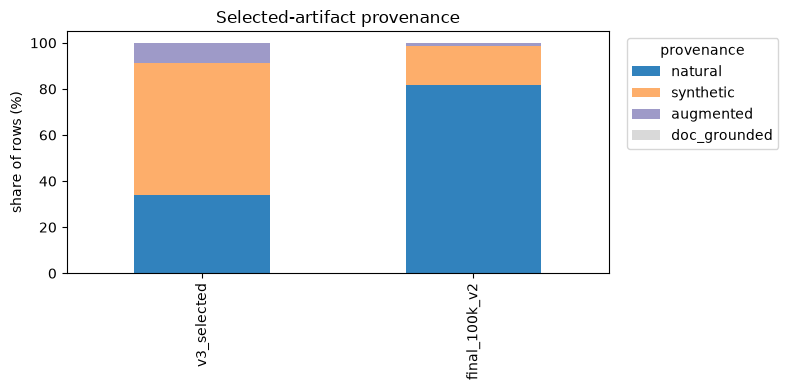

Final 100k-v2: top lanes by row count


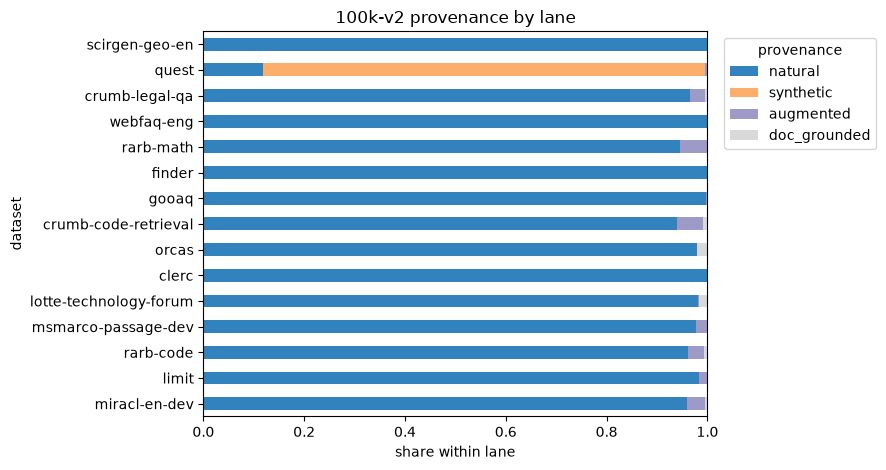

provenance,natural,synthetic,augmented,doc_grounded,n
dataset,,,,,
scirgen-geo-en,1.000,0.000,0.000,0.000,20000
quest,0.118,0.878,0.004,0.001,17377
crumb-legal-qa,0.965,0.000,0.031,0.005,6999
webfaq-eng,0.999,0.000,0.001,0.000,6872
rarb-math,0.947,0.000,0.052,0.001,6676
finder,1.000,0.000,0.000,0.000,5703
gooaq,0.998,0.000,0.002,0.000,5676
crumb-code-retrieval,0.940,0.000,0.052,0.008,3898
orcas,0.979,0.000,0.001,0.020,3065


v3 selected: top lanes by row count


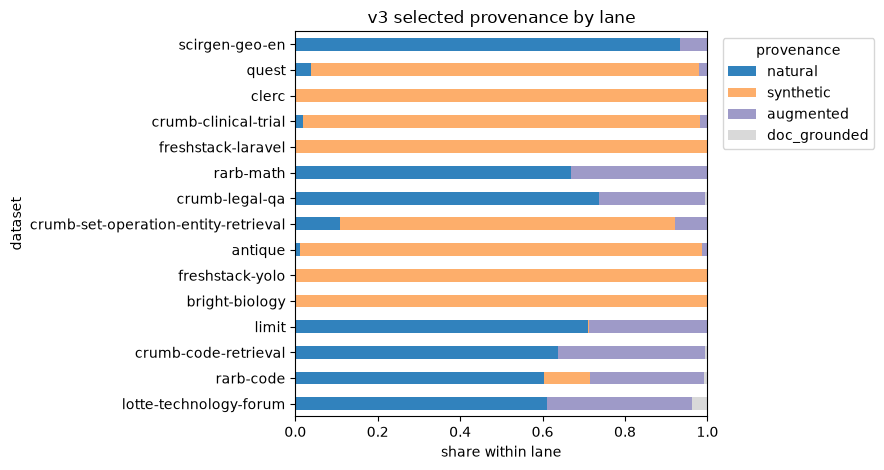

provenance,natural,synthetic,augmented,doc_grounded,n
dataset,,,,,
scirgen-geo-en,0.932,0.000,0.068,0.000,7367
quest,0.038,0.941,0.021,0.000,6545
clerc,0.000,1.000,0.000,0.000,3696
crumb-clinical-trial,0.018,0.965,0.015,0.002,2495
freshstack-laravel,0.000,1.000,0.000,0.000,2381
rarb-math,0.669,0.000,0.329,0.002,2068
crumb-legal-qa,0.738,0.000,0.257,0.005,2003
crumb-set-operation-entity-retrieval,0.108,0.813,0.078,0.001,1817
antique,0.010,0.977,0.012,0.001,1640


In [4]:
PROVENANCE_ORDER = ["natural", "synthetic", "augmented", "doc_grounded"]


def provenance_share(frame: pd.DataFrame) -> pd.Series:
    return frame["provenance"].value_counts(normalize=True).reindex(PROVENANCE_ORDER, fill_value=0.0)


overall_provenance = pd.DataFrame({
    "v3_selected": provenance_share(V3_SELECTED),
    "final_100k_v2": provenance_share(FINAL_PLANNED),
})
display((overall_provenance * 100).round(2).rename_axis("provenance").rename(columns=lambda c: f"{c} (%)"))

ax = (overall_provenance.T * 100).plot.bar(stacked=True, figsize=(8, 4), colormap="tab20c")
ax.set_title("Selected-artifact provenance")
ax.set_ylabel("share of rows (%)")
ax.legend(title="provenance", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()


def lane_provenance(frame: pd.DataFrame, title: str, top_n: int = 15) -> pd.DataFrame:
    tab = pd.crosstab(frame["dataset"], frame["provenance"], normalize="index").reindex(
        columns=PROVENANCE_ORDER, fill_value=0.0
    )
    tab["n"] = frame.groupby("dataset").size()
    view = tab.sort_values("n", ascending=False).head(top_n)
    ax = view[PROVENANCE_ORDER].iloc[::-1].plot.barh(
        stacked=True, figsize=(9, max(4, top_n * .32)), colormap="tab20c"
    )
    ax.set_title(title)
    ax.set_xlabel("share within lane")
    ax.legend(title="provenance", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(); plt.show()
    return view


print("Final 100k-v2: top lanes by row count")
display(lane_provenance(FINAL_PLANNED, "100k-v2 provenance by lane", top_n=15).round(3))
print("v3 selected: top lanes by row count")
display(lane_provenance(V3_SELECTED, "v3 selected provenance by lane", top_n=15).round(3))


## 3b · Eye test: what provenance means in practice

The provenance labels are construction labels, not quality grades. These stable examples
make the categories concrete. `cells` are the planned 100k-v2 targets associated with the
row; they show that a short surface form can still have a deliberate coverage role.

- **natural**: a retained source-lane query;
- **synthetic**: a new query generated to meet a target;
- **augmented**: a source query rewritten or enriched toward a target;
- **doc_grounded**: an enrichment anchored to a corpus-visible surface, with its document
  retained as the answer target.

The examples are illustrative only—never use them to infer aggregate quality. The tables
above remain the evidence for population mix.

In [19]:
# Fixed examples keep the presentation stable and auditable across reruns.
# They are deliberately paired: two examples per construction provenance.
EYE_TEST_KEYS = [
    ("antique", "1017690"), ("antique", "100653"),
    ("quest", "lane-quest-0"), ("quest", "lane-quest-100"),
    ("antique", "aug-bare_acronym-1119420"), ("antique", "aug-bare_acronym-159716"),
    ("antique", "aug-number_inside_natural_question-3078448"),
    ("crumb-clinical-trial", "aug-bibliographic_catalog_identifier-2021-30"),
]
example_order = pd.DataFrame(EYE_TEST_KEYS, columns=["dataset", "query_id"])
examples = example_order.merge(
    FINAL_PLANNED[["dataset", "query_id", "provenance", "query", "cells"]],
    on=["dataset", "query_id"], how="left", validate="one_to_one",
)
assert examples["query"].notna().all(), "A fixed eye-test example disappeared from planned_set"
examples["query_id"] = examples["query_id"].astype(str)
examples["cells"] = examples["cells"].map(lambda xs: ", ".join(xs) if isinstance(xs, (list, tuple)) else str(xs))
examples.index = examples.groupby("provenance").cumcount().add(1)
examples.index.name = "example"

for provenance in PROVENANCE_ORDER:
    view = examples.loc[examples["provenance"].eq(provenance), ["dataset", "query", "cells"]]
    print(f"\n{provenance.replace('_', ' ').title()} — two representative rows")
    display(view)



Natural — two representative rows


,dataset,query,cells
example,,,
1,antique,what is the history of indian music?,['damage_free_query' 'stopword_saturated_midlength']
2,antique,how do I go about getting copies of letters of commendat...,['lightly_damaged_query' 'stopword_saturated_midlength'\...



Synthetic — two representative rows


,dataset,query,cells
example,,,
1,quest,Tortricidae moths found only in Venezuela,['damage_free_query' 'rare_term_query']
2,quest,Timothy Findley novels published in 1990s,['damage_free_query' 'rare_term_query']



Augmented — two representative rows


,dataset,query,cells
example,,,
1,antique,"UV. """" ""light""?",['damage_free_query']
2,antique,SDC inmate,['damage_free_query' 'rare_term_query']



Doc Grounded — two representative rows


,dataset,query,cells
example,,,
1,antique,How do you prevent chicken from drying out when you cook...,['damage_free_query']
2,crumb-clinical-trial,M0 thyroid ablation remnant,['damage_free_query' 'rare_term_query']


## 4 · Cascade decision recovery

This is a recovery funnel, not a strict-decisive count. The first three bars are
route-decided layers: existing L1 decisions, top-10 stronger-leg decisions, and
depth-100 fallback decisions. Queue and unmeasured rows remain separate because they
do not become decisions merely by appearing in the cascade file.


,layer rows,cumulative route-decided
label_layer,,
l1,42871,42871.0
argmax_l1_l2,8132,51003.0
depth100_fallback,5044,56047.0
judge_queue_tied,17252,NaN
judge_queue_zero,6728,NaN
unmeasured_tied,8098,NaN
unmeasured_zero,2955,NaN


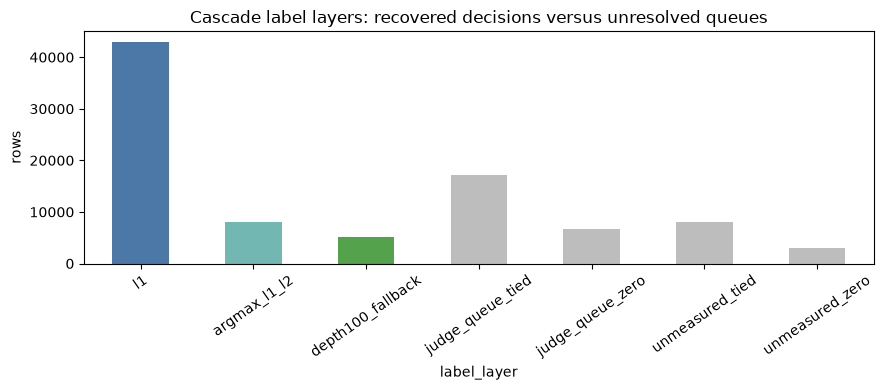

route,dense_only,pure_rrf,sparse_only,unresolved
label_layer,,,,
l1,20472,2403,19996,0
argmax_l1_l2,7058,153,921,0
depth100_fallback,3331,116,1597,0
judge_queue_tied,0,0,0,17252
judge_queue_zero,0,0,0,6728
unmeasured_tied,0,0,0,8098
unmeasured_zero,0,0,0,2955


In [6]:
LAYER_ORDER = [
    "l1", "argmax_l1_l2", "depth100_fallback", "judge_queue_tied",
    "judge_queue_zero", "unmeasured_tied", "unmeasured_zero",
]
layer_counts = CASCADE["label_layer"].value_counts().reindex(LAYER_ORDER, fill_value=0)
decided_layers = layer_counts.loc[["l1", "argmax_l1_l2", "depth100_fallback"]]
funnel = pd.DataFrame({
    "layer rows": layer_counts,
    "cumulative route-decided": [
        decided_layers.iloc[:i + 1].sum() if name in decided_layers.index else np.nan
        for i, name in enumerate(layer_counts.index)
    ],
})
display(funnel)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#4C78A8", "#72B7B2", "#54A24B", "#BDBDBD", "#BDBDBD", "#BDBDBD", "#BDBDBD"]
layer_counts.plot.bar(ax=ax, color=colors)
ax.set_title("Cascade label layers: recovered decisions versus unresolved queues")
ax.set_ylabel("rows")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout(); plt.show()

decision_by_layer = pd.crosstab(CASCADE["label_layer"], CASCADE["route"].fillna("unresolved"))
display(decision_by_layer.reindex(LAYER_ORDER, fill_value=0))


## 4b · Eye test: what the cascade layers look like

One representative row per layer makes the funnel legible. The stored final scores are
shown only to explain the layer, not as a common metric across layers: depth-100 scores
are on a different retrieval-depth ruler. The two queue rows have no route by design;
they are examples of work left for a judge, rather than negative labels.

In [7]:
CASCADE_EYE_TEST_KEYS = [
    ("antique", "1017690", "l1"),
    ("clerc", "101912", "argmax_l1_l2"),
    ("crumb-code-retrieval", "1024", "depth100_fallback"),
    ("clerc", "100288", "judge_queue_tied"),
    ("crumb-code-retrieval", "1092", "judge_queue_zero"),
]
cascade_examples = pd.DataFrame(
    CASCADE_EYE_TEST_KEYS, columns=["dataset", "query_id", "expected layer"]
).merge(
    CASCADE[["dataset", "query_id", "query", "label_layer", "route", *ROUTE_COLS]],
    on=["dataset", "query_id"], how="left", validate="one_to_one",
)
assert cascade_examples["query"].notna().all(), "A fixed cascade eye-test row disappeared"
assert (cascade_examples["expected layer"] == cascade_examples["label_layer"]).all()
cascade_examples["scores (dense / rrf / sparse)"] = cascade_examples[ROUTE_COLS].apply(
    lambda r: " / ".join(f"{v:.3f}" for v in r), axis=1
)
display(cascade_examples[["label_layer", "dataset", "query", "route", "scores (dense / rrf / sparse)"]])


,label_layer,dataset,query,route,scores (dense / rrf / sparse)
0,l1,antique,what is the history of indian music?,dense_only,0.190 / 0.112 / 0.035
1,argmax_l1_l2,clerc,"that exists independently of the breached contract, but ...",dense_only,0.107 / 0.090 / 0.000
2,depth100_fallback,crumb-code-retrieval,You are given a permutation of integers from 1 to n. Exa...,dense_only,0.277 / 0.227 / 0.000
3,judge_queue_tied,clerc,§ 2L1.2. The Government asserts that Rosales waived any ...,NaN,1.000 / 1.000 / 1.000
4,judge_queue_zero,crumb-code-retrieval,There are n lights aligned in a row. These lights are nu...,NaN,0.000 / 0.000 / 0.000


## 5 · Lane scale and concentration

46 lanes across the two corpora | top 12 by combined size:


,union_233k,last_os_distill,total
dataset,,,
scirgen-geo-en,61797,20000,81797
quest,47287,17377,64664
clerc,15190,2049,17239
webfaq-eng,8623,6872,15495
crumb-legal-qa,8000,6999,14999
rarb-math,7912,6676,14588
gooaq,7086,5676,12762
finder,5703,5703,11406
orcas,7618,3065,10683


,top-2 share,HHI,effective lanes (1/HHI)
union_233k,46.8%,0.128,7.82
last_os_distill,41.0%,0.114,8.74


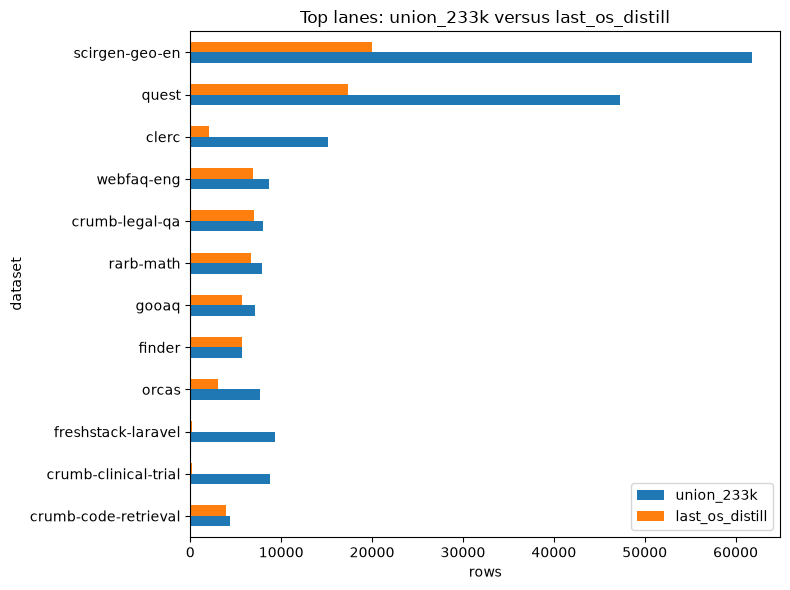

In [8]:
lane_counts = pd.DataFrame({name: lab.groupby("dataset").size() for name, lab in TARGETS.items()}).fillna(0).astype(int)
lane_counts["total"] = lane_counts.sum(axis=1)
print(f"{len(lane_counts)} lanes across the two corpora | top 12 by combined size:")
display(lane_counts.sort_values("total", ascending=False).head(12))


def concentration(series: pd.Series) -> pd.Series:
    share = series / series.sum()
    return pd.Series({
        "top-2 share": share.nlargest(2).sum(),
        "HHI": (share ** 2).sum(),
        "effective lanes (1/HHI)": 1 / (share ** 2).sum(),
    })


display(pd.DataFrame({name: concentration(lab.groupby("dataset").size()) for name, lab in TARGETS.items()}).T.style.format({"top-2 share": "{:.1%}", "HHI": "{:.3f}", "effective lanes (1/HHI)": "{:.2f}"}))

top = lane_counts.sort_values("total", ascending=False).head(12).drop(columns="total").iloc[::-1]
top.plot.barh(figsize=(8, 6), title="Top lanes: union_233k versus last_os_distill")
plt.xlabel("rows"); plt.tight_layout(); plt.show()


## 5b · Eye test: why lanes are not interchangeable

The largest lanes stand for different retrieval situations: specialised scientific prose,
entity/catalogue queries, long legal passages, and code-support questions. Their planned
cells make the intended coverage explicit; lane balance should therefore be read alongside
both provenance and these query forms, not as a count-only statistic.

In [9]:
LANE_EYE_TEST_KEYS = [
    ("scirgen-geo-en", "0049636f-a99f-4743-ad68-84d213587dcc-Causal Antecedent-1"),
    ("quest", "lane-quest-0"),
    ("clerc", "100288"),
    ("freshstack-laravel", "47128903"),
]
lane_examples = pd.DataFrame(LANE_EYE_TEST_KEYS, columns=["dataset", "query_id"]).merge(
    FINAL_PLANNED[["dataset", "query_id", "provenance", "query", "cells"]],
    on=["dataset", "query_id"], how="left", validate="one_to_one",
)
assert lane_examples["query"].notna().all(), "A fixed lane eye-test row disappeared"
lane_examples["cells"] = lane_examples["cells"].map(
    lambda xs: ", ".join(xs) if isinstance(xs, (list, tuple)) else str(xs)
)
display(lane_examples[["dataset", "provenance", "query", "cells"]])


,dataset,provenance,query,cells
0,scirgen-geo-en,natural,What causes difficulties in separating soil and canopy t...,['content_heavy_midlength' 'damage_free_query'\n 'deep_n...
1,quest,synthetic,Tortricidae moths found only in Venezuela,['damage_free_query' 'rare_term_query']
2,clerc,natural,§ 2L1.2. The Government asserts that Rosales waived any ...,['extreme_length_pasted_query' 'fragmented_query' 'heavi...
3,freshstack-laravel,natural,"Errors ""This action is unauthorized."" using Form Request...",['damage_free_query' 'extreme_length_pasted_query' 'frag...


## 6 · Stored route decisions and score-derived outcome shape

stored route-decision share (unresolved means no stored route decision):


,union_233k,last_os_distill
decision,,
dense_only,0.253,0.339
pure_rrf,0.020,0.029
sparse_only,0.439,0.247
unresolved,0.288,0.385


score-derived outcome shape under the canonical score columns:


,union_233k,last_os_distill
shape,,
routes_differ,0.525,0.631
all_tied,0.296,0.263
all_zero,0.179,0.106


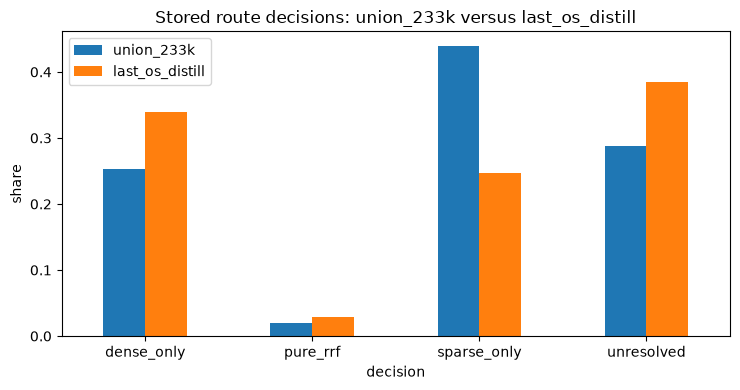

Strict margin >= 0.4 is only comparable within a common scoring ruler; the cascade includes a depth-100 fallback.


,share under canonical score columns
union_233k,0.110
last_os_distill,0.131


In [10]:
decision_order = [*ROUTES, "unresolved"]
decision_mix = pd.DataFrame({
    name: lab["decision"].value_counts(normalize=True).reindex(decision_order, fill_value=0)
    for name, lab in TARGETS.items()
})
print("stored route-decision share (unresolved means no stored route decision):")
display(decision_mix.round(3))
print("score-derived outcome shape under the canonical score columns:")
display(pd.DataFrame({name: lab["shape"].value_counts(normalize=True) for name, lab in TARGETS.items()}).fillna(0).round(3))

decision_mix.plot.bar(figsize=(7.5, 4), title="Stored route decisions: union_233k versus last_os_distill")
plt.ylabel("share"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

print("Strict margin >= 0.4 is only comparable within a common scoring ruler; the cascade includes a depth-100 fallback.")
display(pd.DataFrame({name: lab["strict_decisive"].mean() for name, lab in TARGETS.items()}, index=["share under canonical score columns"]).T.round(3))


## 7 · V2-cell coverage and catalog missingness

This is intentionally a **V2-cell** view: `composition.cells.CELLS` contains the
frozen 44-cell quota set. It is not a complete V3/V4 cell census. The feature catalog
only covers some union rows, so every number in this section is conditioned on a
catalog-present row. The missingness table is therefore part of the result, not a
footnote.


In [11]:
catalog = with_derived(pd.read_parquet(DEFAULT_CATALOG)).drop_duplicates(KEY)
FEAT_COLS = [c for c in catalog.columns if c not in (*KEY, "checkable", "query") and catalog[c].dtype != object]


def covered_rows(lab: pd.DataFrame) -> pd.DataFrame:
    joined = lab[KEY + ["route", "decision", "_source", "provenance"]].merge(catalog, on=KEY, how="left")
    return joined[joined[FEAT_COLS].notna().any(axis=1)]


COVERED = {name: covered_rows(lab) for name, lab in TARGETS.items()}
coverage_rows = []
for name, lab in TARGETS.items():
    cov = COVERED[name]
    coverage_rows.append({"corpus": name, "catalog-indexed rows": len(cov), "all rows": len(lab), "coverage": len(cov) / len(lab)})
coverage = pd.DataFrame(coverage_rows).set_index("corpus")
display(coverage.style.format({"coverage": "{:.1%}"}))

coverage_by_source = UNION.merge(catalog[list(KEY)], on=list(KEY), how="left", indicator=True).groupby("_source")["_merge"].value_counts(normalize=True).unstack(fill_value=0)
display(coverage_by_source.rename(columns={"both": "catalog-present", "left_only": "missing"}).style.format("{:.1%}"))

cell_cov = pd.DataFrame({name: {cell.name: float(cell.select(cov).mean()) for cell in CELLS}
                         for name, cov in COVERED.items()})
cell_cov["mean"] = cell_cov.mean(axis=1)
print(f"{len(CELLS)} frozen V2 cells | coverage on catalog-present rows (top 15 by mean):")
display(cell_cov.sort_values("mean", ascending=False).drop(columns="mean").head(15).round(3))


,catalog-indexed rows,all rows,coverage
corpus,,,
union_233k,125482,233247,53.8%
last_os_distill,74404,91080,81.7%


_merge,missing,right_only,catalog-present
_source,,,
cascade,18.3%,0.0%,81.7%
v2,0.0%,0.0%,100.0%
v3,0.0%,0.0%,100.0%
v3_aug,99.8%,0.0%,0.2%


44 frozen V2 cells | coverage on catalog-present rows (top 15 by mean):


,union_233k,last_os_distill
multi_statement_context_dump,0.206,0.262
deep_nesting_single_sentence,0.154,0.098
verbose_grammatical_request,0.117,0.125
stopword_saturated_midlength,0.102,0.119
extreme_length_pasted_query,0.081,0.130
wide_flat_enumeration,0.094,0.115
high_morphological_variation,0.088,0.081
comparative_multi_entity,0.046,0.062
short_grammatical_question,0.037,0.038
negation_bearing_question,0.033,0.039


## 8 · Taxonomy features — the covered-subset deep cut

Four views: (a) **group-level** fire-rate over the 14 feature groups; (b) **continuous**
features summarised by mean-per-route (fire-rate is meaningless when a feature is always
non-zero); (c) the **structural-identifier tail** (the rare, discriminating signals); and (d)
**taxonomy × route** — which identifiers lean sparse vs dense.

In [12]:
# (a) group-level fire-rate: share of catalog-present rows with ANY nonzero column in the group
GROUPS: dict[str, list[str]] = {}
for c in FEAT_COLS:
    GROUPS.setdefault(c.split(".")[0], []).append(c)
IS_FLAG = {c: set(pd.unique(catalog[c].dropna())) <= {0, 1, 0.0, 1.0} for c in FEAT_COLS}
print(f"{len(FEAT_COLS)} feature cols in {len(GROUPS)} groups | "
      f"{sum(IS_FLAG.values())} binary flags, {sum(not v for v in IS_FLAG.values())} continuous")

group_fire = pd.DataFrame({
    name: {g: float((cov[cols] != 0).any(axis=1).mean()) for g, cols in GROUPS.items()}
    for name, cov in COVERED.items()
})
display(group_fire.round(3).sort_values("union_233k", ascending=False))

83 feature cols in 14 groups | 11 binary flags, 72 continuous


,union_233k,last_os_distill
length,1.000,1.000
syntactic_depth,1.000,1.000
natural_language_signal,0.980,0.977
stopword_ratio,0.959,0.956
morphology,0.916,0.898
coordination,0.429,0.426
sentence_markers,0.321,0.351
structured_identifiers,0.316,0.387
derived,0.316,0.387
logical_structures,0.069,0.111


In [13]:
# (b) continuous features: mean by route (union_233k) — the signal fire-rate can't show
CONT = ["term_rarity.min_zipf", "term_rarity.rare_share", "length.length_words",
        "syntactic_depth.nesting_depth", "stopword_ratio.stopword_ratio"]
CONT = [c for c in CONT if c in FEAT_COLS]
cov_u = COVERED["union_233k"]
display(cov_u.groupby("route")[CONT].mean().round(3))

,term_rarity.min_zipf,term_rarity.rare_share,length.length_words,syntactic_depth.nesting_depth,stopword_ratio.stopword_ratio
route,,,,,
dense_only,0.19,0.015,33.175,5.611,0.369
pure_rrf,0.15,0.010,33.019,5.124,0.352
sparse_only,0.11,0.009,32.998,6.471,0.350


In [14]:
# (c)+(d) structural-identifier tail x route: fire-rate per identifier, per route, per corpus
IDENT = [c for c in FEAT_COLS if c.startswith("structured_identifiers.")]

def ident_by_route(cov: pd.DataFrame, top_n: int = 12) -> pd.DataFrame:
    order = (cov[IDENT] != 0).mean().sort_values(ascending=False).head(top_n).index
    out = {"all": (cov[order] != 0).mean()}
    for r in ROUTES:
        out[r] = (cov.loc[cov["route"] == r, order] != 0).mean()
    df = pd.DataFrame(out)
    df.index = [i.split(".", 1)[1] for i in df.index]
    df["sparse_lean"] = df["sparse_only"] - df["dense_only"]     # >0 => fires more on sparse than dense
    return df.round(4)

for name, cov in COVERED.items():
    print(f"\n{name} — top identifiers, fire-rate by route (sparse_lean = sparse - dense):")
    display(ident_by_route(cov).sort_values("sparse_lean", ascending=False))


union_233k — top identifiers, fire-rate by route (sparse_lean = sparse - dense):


,all,dense_only,pure_rrf,sparse_only,sparse_lean
bic,0.0227,0.0079,0.0197,0.0497,0.0418
stock_ticker_like,0.1601,0.1575,0.1499,0.1920,0.0345
legal_citation,0.0157,0.0046,0.0120,0.0373,0.0326
http_status_code,0.0143,0.0049,0.0141,0.0324,0.0276
error_code_like,0.0042,0.0030,0.0070,0.0057,0.0027
version_string,0.0126,0.0131,0.0184,0.0142,0.0011
value_with_unit,0.0051,0.0054,0.0097,0.0061,0.0007
uri,0.0040,0.0049,0.0077,0.0038,-0.0011
host_port,0.0039,0.0047,0.0057,0.0036,-0.0011
currency_amount,0.0213,0.0325,0.0141,0.0159,-0.0166



last_os_distill — top identifiers, fire-rate by route (sparse_lean = sparse - dense):


,all,dense_only,pure_rrf,sparse_only,sparse_lean
bic,0.0308,0.0089,0.0211,0.0831,0.0742
legal_citation,0.0211,0.0052,0.0128,0.0630,0.0578
stock_ticker_like,0.1782,0.1713,0.1600,0.2218,0.0504
http_status_code,0.0194,0.0055,0.0153,0.0543,0.0487
number,0.2331,0.2401,0.1964,0.2689,0.0288
version_string,0.0181,0.0157,0.0211,0.0218,0.0062
file_path,0.0056,0.0043,0.0128,0.0093,0.0050
error_code_like,0.0053,0.0036,0.0087,0.0072,0.0035
value_with_unit,0.0054,0.0053,0.0095,0.0063,0.0009
social_handle,0.0057,0.0051,0.0128,0.0055,0.0004


## 9 · What this notebook can and cannot claim

**What is now visible:**

- the union's winning source after deduplication, rather than only its final size;
- augmentation provenance overall and by lane for v3 and 100k-v2 selected artifacts;
- cascade recovery layers and the unresolved remainder;
- lane concentration, stored route decisions, and catalog coverage.

**Interpretation limits:**

- `last_os_distill` is inside `union_233k`; their side-by-side comparison is context, not a causal experiment.
- the cascade mixes Top-10 labels with a depth-100 fallback. Its layer must travel with
  any downstream analysis; do not use one pooled strict-decisive percentage as if every
  score came from the same ruler.
- V2-cell and taxonomy panels remain conditional on catalog presence. The union's
  uncatalogued material needs an offline extraction pass before this notebook can claim
  full-population feature coverage.
- source/provenance balance, route-decision balance, and held-out router quality are
  distinct. This notebook describes training substrate; it does not prove a router gain.

The next analysis, if needed, is a lane × provenance × outcome heatmap using a single
frozen scoring regime and catalog version. That would test whether generated material
adds decisive, transferable query shapes rather than merely increasing row count.
